In [ ]:
# =========================================================
# CELDA 1: Cargar librerías y preparar la base de datos
# ---------------------------------------------------------
# Objetivo:
#   - Importar las librerías necesarias para el análisis.
#   - Leer la base de datos de V-Dem.
#   - Filtrar el período 2000–2023.
#
# Además:
#   Se configura la visualización de tablas y se genera una
#   lista con todos los países disponibles para facilitar
#   validaciones posteriores.
#
# Resultado:
#   La base queda lista para realizar comparaciones entre
#   pares de países.
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from difflib import get_close_matches

pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 55)

df = pd.read_csv('/content/vdem_exclusion_subset.csv')
df21 = df[(df['year'] >= 2000) & (df['year'] <= 2023)].copy()

PAISES_DISPONIBLES = sorted(df21['country_name'].unique())

In [ ]:
# =========================================================
# CELDA 2: Diccionario de nombres descriptivos
# ---------------------------------------------------------
# Objetivo:
#   Traducir los nombres técnicos de las variables V-Dem a
#   etiquetas comprensibles para la interpretación de los
#   resultados.
#
# Además:
#   Se define una lista de variables clave que servirán como
#   conjunto mínimo para una comparación rápida entre países.
#
# Resultado:
#   Los reportes y tablas mostrarán nombres legibles en lugar
#   de códigos técnicos.
# =========================================================

NOMBRES_VARIABLES = {
    'v2xpe_exlsocgr':  'Exclusión política por grupo social (etnia/religión)',
    'v2xpe_exlgender': 'Exclusión política por género',
    'v2xpe_exlecon':   'Exclusión política por clase económica',
    'v2xpe_exlpol':    'Exclusión política por afiliación política',
    'v2xpe_exlgeo':    'Exclusión política por ubicación geográfica',
    'v2pepwrsoc':      'Distribución de poder entre grupos sociales',
    'v2pepwrgen':      'Distribución de poder por género',
    'v2pepwrort':      'Distribución de poder por orientación sexual',
    'v2pepwrses':      'Distribución de poder por clase socioeconómica',
    'v2pepwrgeo':      'Distribución de poder por región geográfica',
    'v2clacjstm':      'Acceso a la justicia (hombres)',
    'v2clacjstw':      'Acceso a la justicia (mujeres)',
    'v2cldmovem':      'Libertad de movimiento (hombres)',
    'v2cldmovew':      'Libertad de movimiento (mujeres)',
    'v2clsocgrp':      'Igualdad ante la ley entre grupos sociales',
    'v2x_clpriv':      'Índice de libertades civiles',
    'v2csgender':      'Represión de organizaciones civiles de mujeres',
    'v2csantimv':      'Restricción a movimientos anti-discriminación (incl. LGBT)',
    'v2csrlgrep':      'Represión de grupos religiosos',
    'v2csrlgcon':      'Conflicto entre grupos religiosos',
    'v2peedueq':       'Equidad en acceso a educación',
    'v2pehealth':      'Equidad en acceso a salud',
    'v2peapsecon':     'Poder político por clase económica',
    'v2peapssoc':      'Poder político por estatus social',
    'v2x_gender':      'Índice de empoderamiento de mujeres',
    'v2x_suffr':       'Sufragio universal',
    'v2x_polyarchy':   'Índice de poliarquía (nivel de democracia electoral)',
    'v2x_libdem':      'Índice de democracia liberal',
    'e_gdppc':         'PIB per cápita',
}

# Variables centrales para la comparación rápida (las demás se pueden
# agregar a esta lista si quieres profundizar en otra dimensión)
VARIABLES_CLAVE = [
    'v2xpe_exlsocgr', 'v2xpe_exlgender', 'v2pepwrsoc', 'v2pepwrgen',
    'v2pepwrort', 'v2clsocgrp', 'v2csgender', 'v2csantimv',
    'v2x_gender', 'v2x_polyarchy', 'v2x_libdem'
]

In [ ]:
# =========================================================
# CELDA 3: Validar nombres de países
# ---------------------------------------------------------
# Objetivo:
#   Verificar que el país ingresado exista exactamente en la
#   base de datos.
#
# Si el nombre no coincide:
#   - Se buscan coincidencias aproximadas.
#   - Se sugieren alternativas similares.
#
# Esto evita errores comunes de escritura y facilita el uso
# de la herramienta.
#
# Resultado:
#   Devuelve un nombre válido o una sugerencia para corregir
#   la búsqueda.
# =========================================================

def validar_pais(nombre):
    if nombre in PAISES_DISPONIBLES:
        return nombre
    sugerencias = get_close_matches(nombre, PAISES_DISPONIBLES, n=3, cutoff=0.5)
    if sugerencias:
        print(f"'{nombre}' no está exacto en el dataset. ¿Quisiste decir: {sugerencias}?")
    else:
        print(f"'{nombre}' no se encontró y no hay sugerencias cercanas. Revisa la lista completa en PAISES_DISPONIBLES.")
    return None

In [ ]:
# =========================================================
# CELDA 4: Comparación descriptiva entre dos países
# ---------------------------------------------------------
# Objetivo:
#   Construir un perfil comparativo entre dos países para el
#   período 2000–2023.
#
# Se generan dos tablas:
#
#   1. Promedios históricos:
#      Comparación lado a lado de las variables seleccionadas.
#
#   2. Tendencias temporales:
#      Comparación entre los valores observados en 2000 y
#      2023, junto con el cambio acumulado.
#
# Esto permite responder preguntas como:
#
#   - ¿Cuál presenta mayor exclusión promedio?
#   - ¿Cuál es más democrático?
#   - ¿Cuál mejoró o empeoró más durante el período?
#
# Resultado:
#   Se generan tablas comparativas y se preparan los datos
#   necesarios para análisis posteriores.
# =========================================================

def comparar_paises(pais1, pais2, variables=VARIABLES_CLAVE):
    p1 = validar_pais(pais1)
    p2 = validar_pais(pais2)
    if p1 is None or p2 is None:
        return None

    datos1 = df21[df21['country_name'] == p1]
    datos2 = df21[df21['country_name'] == p2]

    # --- Tabla 1: promedios 2000-2023, lado a lado ---
    filas = []
    for var in variables:
        v1 = datos1[var].mean()
        v2 = datos2[var].mean()
        filas.append({
            'Variable': NOMBRES_VARIABLES.get(var, var),
            p1: round(v1, 3) if pd.notna(v1) else np.nan,
            p2: round(v2, 3) if pd.notna(v2) else np.nan,
            'Diferencia (P1 - P2)': round(v1 - v2, 3) if pd.notna(v1) and pd.notna(v2) else np.nan
        })
    tabla_promedios = pd.DataFrame(filas).set_index('Variable')

    print(f"\n{'='*90}\nCOMPARACIÓN: {p1} vs. {p2} (promedios 2000-2023)\n{'='*90}")
    print(tabla_promedios.to_string())

    # --- Tabla 2: cambio 2000 -> 2023 (tendencia), para variables clave de exclusión ---
    vars_tendencia = ['v2xpe_exlsocgr', 'v2xpe_exlgender', 'v2x_polyarchy']
    filas_tend = []
    for var in vars_tendencia:
        for pais, datos in [(p1, datos1), (p2, datos2)]:
            serie = datos.set_index('year')[var]
            v2000 = serie.get(2000, np.nan)
            v2023 = serie.get(2023, np.nan)
            filas_tend.append({
                'Variable': NOMBRES_VARIABLES.get(var, var),
                'País': pais,
                '2000': round(v2000, 3) if pd.notna(v2000) else np.nan,
                '2023': round(v2023, 3) if pd.notna(v2023) else np.nan,
                'Cambio': round(v2023 - v2000, 3) if pd.notna(v2000) and pd.notna(v2023) else np.nan
            })
    tabla_tendencia = pd.DataFrame(filas_tend)

    print(f"\n--- Tendencia 2000 -> 2023 ---")
    print(tabla_tendencia.to_string(index=False))

    return tabla_promedios, tabla_tendencia, datos1, datos2, p1, p2


In [ ]:
# =========================================================
# CELDA 5: Comparar exclusión observada vs. exclusión esperada
# ---------------------------------------------------------
# Objetivo:
#   Evaluar si el nivel de exclusión de cada país es mayor o
#   menor al esperado según su democracia, riqueza y región.
#
# Metodología:
#   Se ajusta una regresión donde la exclusión es explicada
#   por:
#
#       • Democracia electoral.
#       • PIB per cápita (log).
#       • Región geográfica.
#
# Posteriormente se calcula el residual promedio de cada país.
#
# Interpretación:
#
#   Residual positivo:
#       El país excluye más de lo esperado.
#
#   Residual negativo:
#       El país excluye menos de lo esperado.
#
# Resultado:
#   Se obtiene una interpretación contextualizada del nivel
#   de exclusión observado en cada país.
# =========================================================

def comparar_residuales(datos1, datos2, p1, p2, variable_objetivo='v2xpe_exlsocgr'):
    sub = df21.dropna(subset=[variable_objetivo, 'v2x_polyarchy', 'e_gdppc', 'e_regiongeo']).copy()
    sub['log_gdppc'] = np.log(sub['e_gdppc'])
    X = pd.get_dummies(sub[['v2x_polyarchy', 'log_gdppc', 'e_regiongeo']],
                        columns=['e_regiongeo'], drop_first=True)
    X = sm.add_constant(X.astype(float))
    y = sub[variable_objetivo]
    modelo = sm.OLS(y, X).fit()
    sub['residual'] = modelo.resid

    print(f"\n--- ¿'{NOMBRES_VARIABLES.get(variable_objetivo, variable_objetivo)}' es más o menos de lo esperado? ---")
    for pais in [p1, p2]:
        res_pais = sub[sub['country_name'] == pais]['residual'].mean()
        if pd.isna(res_pais):
            print(f"{pais}: sin datos suficientes para calcular el residual.")
        elif res_pais > 0:
            print(f"{pais}: excluye MÁS de lo que su democracia/riqueza predicen (residual = {res_pais:.3f})")
        else:
            print(f"{pais}: excluye MENOS de lo que su democracia/riqueza predicen (residual = {res_pais:.3f})")

In [ ]:
# =========================================================
# CELDA 6: Visualizar trayectorias históricas
# ---------------------------------------------------------
# Objetivo:
#   Comparar gráficamente la evolución temporal de ambos
#   países en variables seleccionadas.
#
# El gráfico permite observar:
#
#   - Niveles relativos.
#   - Tendencias de largo plazo.
#   - Momentos de convergencia o divergencia.
#   - Cambios bruscos o periodos de estabilidad.
#
# Resultado:
#   Se generan gráficos comparativos para facilitar la
#   interpretación visual de las trayectorias nacionales.
# =========================================================

def graficar_comparacion(datos1, datos2, p1, p2, variables=['v2xpe_exlsocgr', 'v2xpe_exlgender', 'v2x_polyarchy']):
    fig, axes = plt.subplots(1, len(variables), figsize=(6*len(variables), 4.5))
    if len(variables) == 1:
        axes = [axes]

    for ax, var in zip(axes, variables):
        ax.plot(datos1['year'], datos1[var], marker='o', markersize=3, label=p1)
        ax.plot(datos2['year'], datos2[var], marker='s', markersize=3, label=p2)
        ax.set_title(NOMBRES_VARIABLES.get(var, var), fontsize=10)
        ax.set_xlabel('Año')
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# =========================================================
# CELDA 7: Ejecutar el análisis completo
# ---------------------------------------------------------
# Objetivo:
#   Integrar todas las funciones anteriores en un único flujo
#   de trabajo.
#
# El procedimiento realiza automáticamente:
#
#   1. Comparación descriptiva.
#   2. Análisis de tendencias.
#   3. Comparación de residuales para exclusión social.
#   4. Comparación de residuales para exclusión de género.
#   5. Visualización gráfica.
#
# Resultado:
#   Se obtiene un informe comparativo completo entre dos
#   países con una sola llamada a la función.
# =========================================================

def analisis_completo(pais1, pais2):
    resultado = comparar_paises(pais1, pais2)
    if resultado is None:
        return
    tabla_promedios, tabla_tendencia, datos1, datos2, p1, p2 = resultado

    comparar_residuales(datos1, datos2, p1, p2, 'v2xpe_exlsocgr')
    comparar_residuales(datos1, datos2, p1, p2, 'v2xpe_exlgender')

    graficar_comparacion(datos1, datos2, p1, p2)

    return tabla_promedios, tabla_tendencia


COMPARACIÓN: Chad vs. Iraq (promedios 2000-2023)
                                                             Chad   Iraq  Diferencia (P1 - P2)
Variable                                                                                      
Exclusión política por grupo social (etnia/religión)        0.831  0.826                 0.005
Exclusión política por género                               0.728  0.877                -0.149
Distribución de poder entre grupos sociales                -1.547  0.183                -1.731
Distribución de poder por género                           -0.115 -0.397                 0.281
Distribución de poder por orientación sexual               -1.564 -1.444                -0.120
Igualdad ante la ley entre grupos sociales                 -0.413  0.191                -0.603
Represión de organizaciones civiles de mujeres              1.101  0.758                 0.343
Restricción a movimientos anti-discriminación (incl. LGBT)  1.330  0.868                 0.462


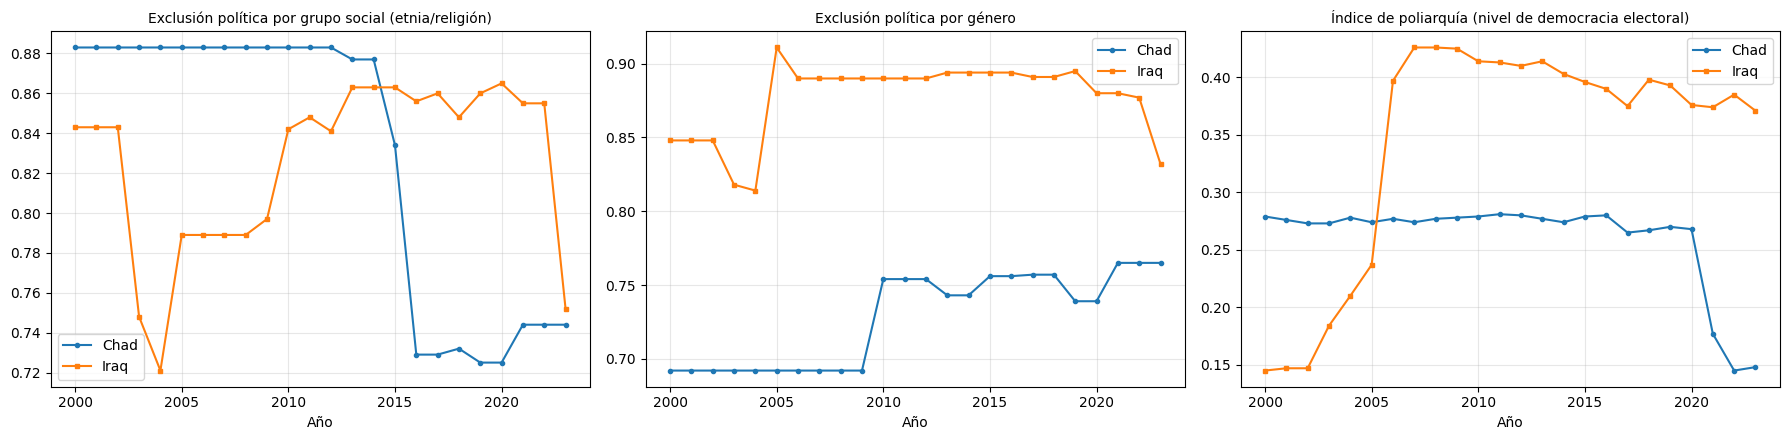

(                                                          Chad   Iraq  Diferencia (P1 - P2)
 Variable                                                                                   
 Exclusión política por grupo social (etnia/religión)     0.831  0.826                 0.005
 Exclusión política por género                            0.728  0.877                -0.149
 Distribución de poder entre grupos sociales             -1.547  0.183                -1.731
 Distribución de poder por género                        -0.115 -0.397                 0.281
 Distribución de poder por orientación sexual            -1.564 -1.444                -0.120
 Igualdad ante la ley entre grupos sociales              -0.413  0.191                -0.603
 Represión de organizaciones civiles de mujeres           1.101  0.758                 0.343
 Restricción a movimientos anti-discriminación (incl....  1.330  0.868                 0.462
 Índice de empoderamiento de mujeres                      0.508  0.496

In [ ]:
# =========================================================
# CELDA 8: Ejemplo de uso
# ---------------------------------------------------------
# Objetivo:
#   Ejecutar el análisis completo para un par específico de
#   países.
#
# Para utilizar otros casos:
#   Sustituye los nombres por cualquier país disponible en
#   la variable PAISES_DISPONIBLES.
#
# Resultado:
#   Se genera automáticamente el informe comparativo para el
#   par seleccionado.
# =========================================================

analisis_completo('Chad', 'Iraq')

In [ ]:
# =========================================================
# CELDA 9: Comparación interactiva
# ---------------------------------------------------------
# Objetivo:
#   Permitir que el usuario seleccione países mediante
#   entrada directa de texto, sin necesidad de modificar el
#   código fuente.
#
# Uso recomendado:
#   Explorar rápidamente distintos pares de países durante
#   la fase de investigación o redacción narrativa.
#
# Resultado:
#   Cada ejecución genera un nuevo informe comparativo para
#   el par ingresado por el usuario.
# =========================================================

pais_a = input("Escribe el primer país: ").strip()
pais_b = input("Escribe el segundo país: ").strip()
analisis_completo(pais_a, pais_b)

KeyboardInterrupt: Interrupted by user